In [ ]:
# =========================
# INSTALL REQUIRED PACKAGE
# =========================
!pip install pytorch-tabnet -q

# =========================
# IMPORTS
# =========================
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader, TensorDataset
from pytorch_tabnet.tab_model import TabNetClassifier

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# =========================
# REPRODUCIBILITY
# =========================
np.random.seed(42)
torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# =========================
# LOAD DATASET
# =========================
df = pd.read_csv("nutrition_health_survey.csv")
df = df.dropna()

if "SEQN" in df.columns:
    df = df.drop(columns=["SEQN"])

# =========================
# CREATE DIABETES TARGET
# =========================
# Diabetes = 1 if self-reported diabetes OR glucose >= 126
df["Diabetes"] = np.where(
    (df["DIQ010"] == 1) | (df["LBXGLU"] >= 126),
    1,
    0
)

print("Class distribution:")
print(df["Diabetes"].value_counts())

# Drop target-defining columns to reduce leakage
X = df.drop(columns=["DIQ010", "Diabetes", "LBXGLU"])
y = df["Diabetes"]

X = pd.get_dummies(X, drop_first=True)

feature_names = X.columns.tolist()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y.values,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
y_train_tensor = torch.tensor(y_train, dtype=torch.long).to(device)
y_test_tensor = torch.tensor(y_test, dtype=torch.long).to(device)

Using device: cpu
Class distribution:
Diabetes
0    287
1     14
Name: count, dtype: int64



Early stopping occurred at epoch 22 with best_epoch = 2 and best_test_accuracy = 0.96721
TabNet Accuracy: 0.9672131147540983
              precision    recall  f1-score   support

           0       0.97      1.00      0.98        58
           1       1.00      0.33      0.50         3

    accuracy                           0.97        61
   macro avg       0.98      0.67      0.74        61
weighted avg       0.97      0.97      0.96        61



/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


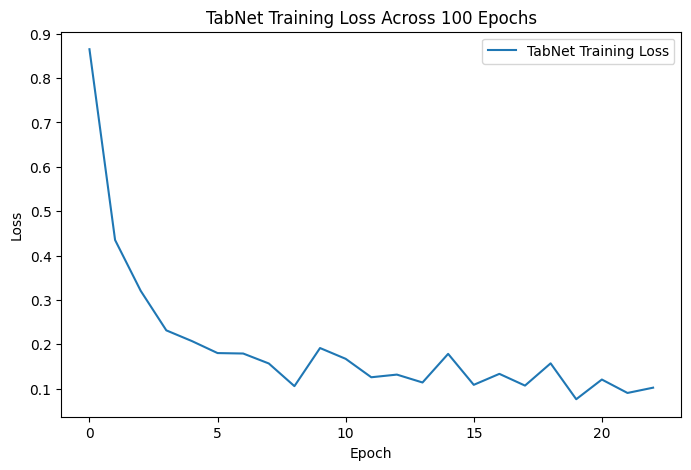

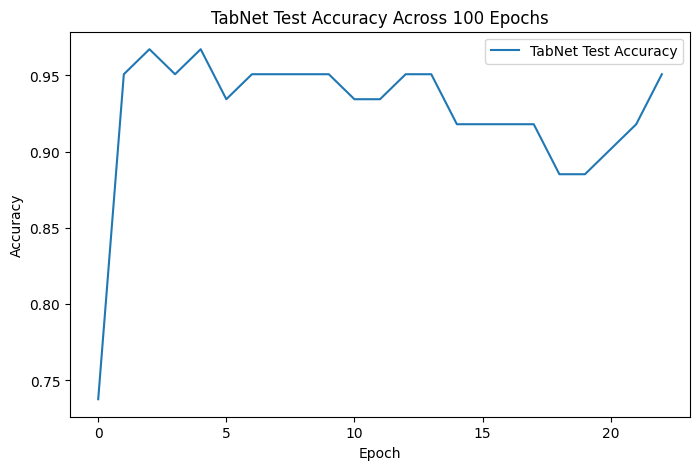

In [ ]:
tabnet_model = TabNetClassifier(verbose=False)

tabnet_model.fit(
    X_train=X_train,
    y_train=y_train,
    eval_set=[(X_test, y_test)],
    eval_name=["test"],
    eval_metric=["accuracy"],
    max_epochs=100,
    patience=20,
    batch_size=64,
    virtual_batch_size=32
)

tabnet_preds = tabnet_model.predict(X_test)
tabnet_probs = tabnet_model.predict_proba(X_test)[:, 1]
tabnet_acc = accuracy_score(y_test, tabnet_preds)

print("TabNet Accuracy:", tabnet_acc)
print(classification_report(y_test, tabnet_preds))

# TabNet epoch plot
plt.figure(figsize=(8, 5))
plt.plot(tabnet_model.history["loss"], label="TabNet Training Loss")
plt.title("TabNet Training Loss Across 100 Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

# TabNet validation accuracy plot
plt.figure(figsize=(8, 5))
plt.plot(tabnet_model.history["test_accuracy"], label="TabNet Test Accuracy")
plt.title("TabNet Test Accuracy Across 100 Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [ ]:
def train_torch_model(model, X_train, y_train, epochs=100, batch_size=64):
    dataset = TensorDataset(X_train, y_train)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    losses = []

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for xb, yb in loader:
            optimizer.zero_grad()
            outputs = model(xb)
            loss = criterion(outputs, yb)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(loader)
        losses.append(avg_loss)

        if epoch % 10 == 0:
            print(f"Epoch {epoch}, Loss: {avg_loss:.4f}")

    return losses

Epoch 0, Loss: 0.4464
Epoch 10, Loss: 0.0819
Epoch 20, Loss: 0.0790
Epoch 30, Loss: 0.0831
Epoch 40, Loss: 0.0628
Epoch 50, Loss: 0.0775
Epoch 60, Loss: 0.0670
Epoch 70, Loss: 0.0550
Epoch 80, Loss: 0.0403
Epoch 90, Loss: 0.0539
TabTransformer Accuracy: 0.9508196721311475
              precision    recall  f1-score   support

           0       0.97      0.98      0.97        58
           1       0.50      0.33      0.40         3

    accuracy                           0.95        61
   macro avg       0.73      0.66      0.69        61
weighted avg       0.94      0.95      0.95        61



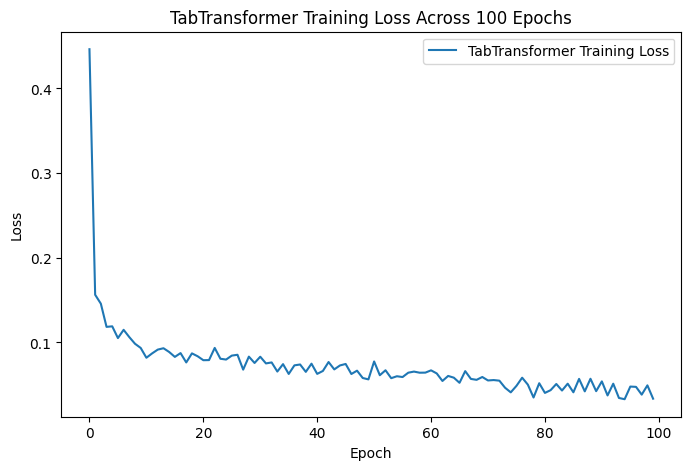

In [ ]:
tabtransformer_model = TabTransformer(input_dim=X_train.shape[1]).to(device)

tabtransformer_losses = train_torch_model(
    tabtransformer_model,
    X_train_tensor,
    y_train_tensor,
    epochs=100
)

tabtransformer_model.eval()

with torch.no_grad():
    outputs = tabtransformer_model(X_test_tensor)
    tabtransformer_probs = torch.softmax(outputs, dim=1)[:, 1].cpu().numpy()
    tabtransformer_preds = torch.argmax(outputs, dim=1).cpu().numpy()

tabtransformer_acc = accuracy_score(y_test, tabtransformer_preds)

print("TabTransformer Accuracy:", tabtransformer_acc)
print(classification_report(y_test, tabtransformer_preds))

# TabTransformer epoch plot
plt.figure(figsize=(8, 5))
plt.plot(tabtransformer_losses, label="TabTransformer Training Loss")
plt.title("TabTransformer Training Loss Across 100 Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

Epoch 0, Loss: 0.3598
Epoch 10, Loss: 0.0847
Epoch 20, Loss: 0.0745
Epoch 30, Loss: 0.0836
Epoch 40, Loss: 0.0529
Epoch 50, Loss: 0.0465
Epoch 60, Loss: 0.0490
Epoch 70, Loss: 0.0789
Epoch 80, Loss: 0.0581
Epoch 90, Loss: 0.0727
ResNetTabular Accuracy: 0.9508196721311475
              precision    recall  f1-score   support

           0       0.97      0.98      0.97        58
           1       0.50      0.33      0.40         3

    accuracy                           0.95        61
   macro avg       0.73      0.66      0.69        61
weighted avg       0.94      0.95      0.95        61



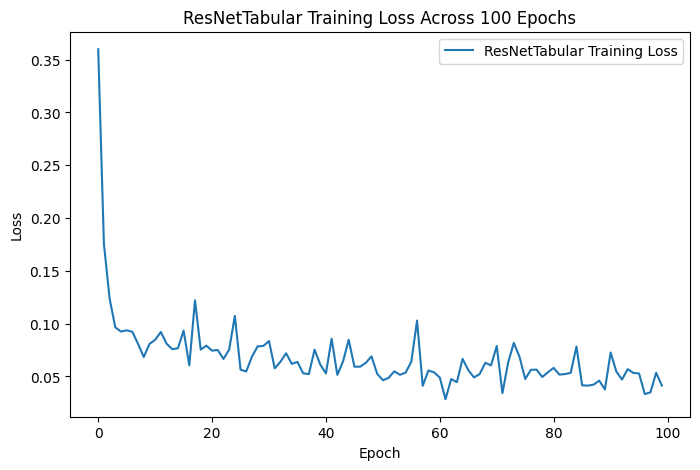

In [ ]:
resnet_model = ResNetTabular(input_dim=X_train.shape[1]).to(device)

resnet_losses = train_torch_model(
    resnet_model,
    X_train_tensor,
    y_train_tensor,
    epochs=100
)

resnet_model.eval()

with torch.no_grad():
    outputs = resnet_model(X_test_tensor)
    resnet_probs = torch.softmax(outputs, dim=1)[:, 1].cpu().numpy()
    resnet_preds = torch.argmax(outputs, dim=1).cpu().numpy()

resnet_acc = accuracy_score(y_test, resnet_preds)

print("ResNetTabular Accuracy:", resnet_acc)
print(classification_report(y_test, resnet_preds))

# ResNetTabular epoch plot
plt.figure(figsize=(8, 5))
plt.plot(resnet_losses, label="ResNetTabular Training Loss")
plt.title("ResNetTabular Training Loss Across 100 Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

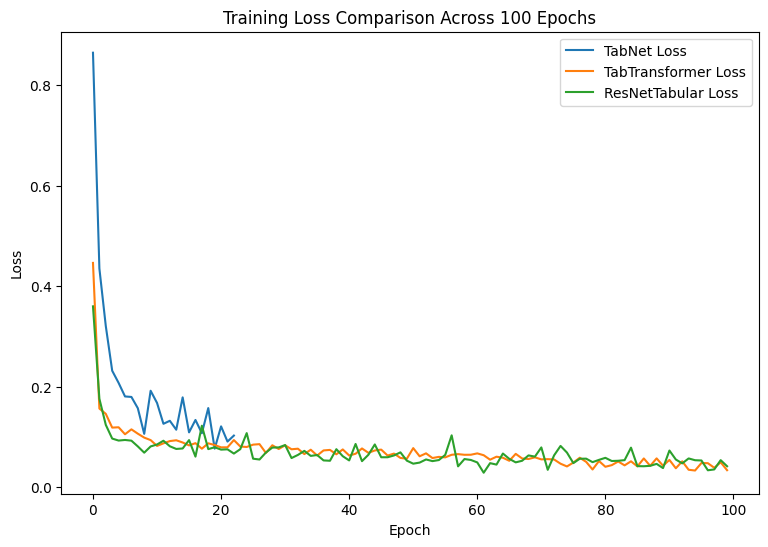

In [ ]:
plt.figure(figsize=(9, 6))

plt.plot(tabnet_model.history["loss"], label="TabNet Loss")
plt.plot(tabtransformer_losses, label="TabTransformer Loss")
plt.plot(resnet_losses, label="ResNetTabular Loss")

plt.title("Training Loss Comparison Across 100 Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

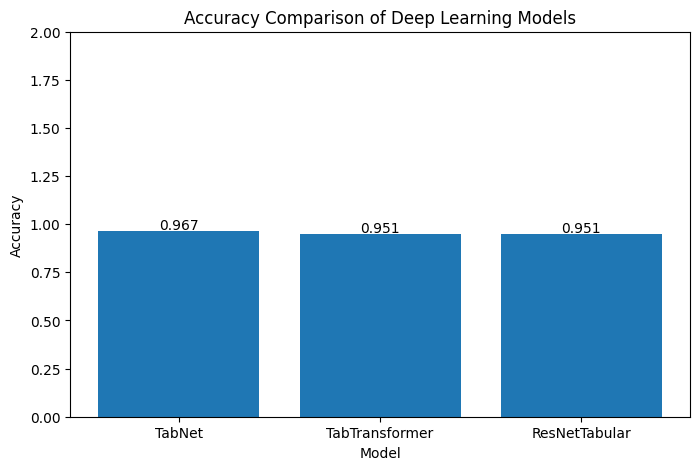

In [ ]:
# =========================
# ACCURACY COMPARISON GRAPH
# =========================

model_names = ["TabNet", "TabTransformer", "ResNetTabular"]
accuracies = [tabnet_acc, tabtransformer_acc, resnet_acc]

plt.figure(figsize=(8, 5))
bars = plt.bar(model_names, accuracies)

for bar in bars:
    value = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.005,
        f"{value:.3f}",
        ha="center"
    )

plt.title("Accuracy Comparison of Deep Learning Models")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0, 2)
plt.show()

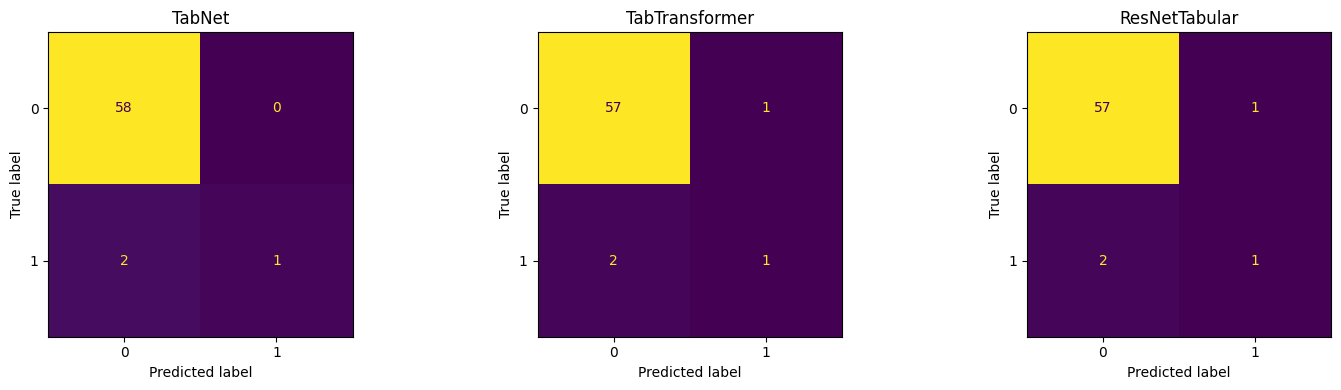

In [ ]:
# =========================
# CONFUSION MATRIX GRAPHS
# =========================

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

models_predictions = {
    "TabNet": tabnet_preds,
    "TabTransformer": tabtransformer_preds,
    "ResNetTabular": resnet_preds
}

for ax, (name, preds) in zip(axes, models_predictions.items()):
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=ax, values_format="d", colorbar=False)
    ax.set_title(name)

plt.tight_layout()
plt.show()

In [ ]:
# =========================
# RISK STRATIFICATION
# =========================

def risk_level(prob):
    if prob < 0.30:
        return "Low Risk"
    elif prob < 0.70:
        return "Medium Risk"
    else:
        return "High Risk"


results_tabnet = pd.DataFrame({
    "Actual": y_test,
    "Predicted": tabnet_preds,
    "Probability": tabnet_probs,
    "Risk_Level": [risk_level(p) for p in tabnet_probs]
})

results_tabtransformer = pd.DataFrame({
    "Actual": y_test,
    "Predicted": tabtransformer_preds,
    "Probability": tabtransformer_probs,
    "Risk_Level": [risk_level(p) for p in tabtransformer_probs]
})

results_resnet = pd.DataFrame({
    "Actual": y_test,
    "Predicted": resnet_preds,
    "Probability": resnet_probs,
    "Risk_Level": [risk_level(p) for p in resnet_probs]
})

display(results_tabnet.head())
display(results_tabtransformer.head())
display(results_resnet.head())

,Actual,Predicted,Probability,Risk_Level
0,0,0,2.408488e-02,Low Risk
1,0,0,6.598942e-02,Low Risk
2,0,0,1.967601e-01,Low Risk
3,0,0,1.745822e-01,Low Risk
4,0,0,6.863108e-12,Low Risk


,Actual,Predicted,Probability,Risk_Level
0,0,0,0.000493,Low Risk
1,0,0,0.000079,Low Risk
2,0,0,0.000564,Low Risk
3,0,0,0.000003,Low Risk
4,0,1,0.793721,High Risk


,Actual,Predicted,Probability,Risk_Level
0,0,0,0.000017,Low Risk
1,0,0,0.000022,Low Risk
2,0,0,0.000291,Low Risk
3,0,0,0.000024,Low Risk
4,0,1,0.883622,High Risk


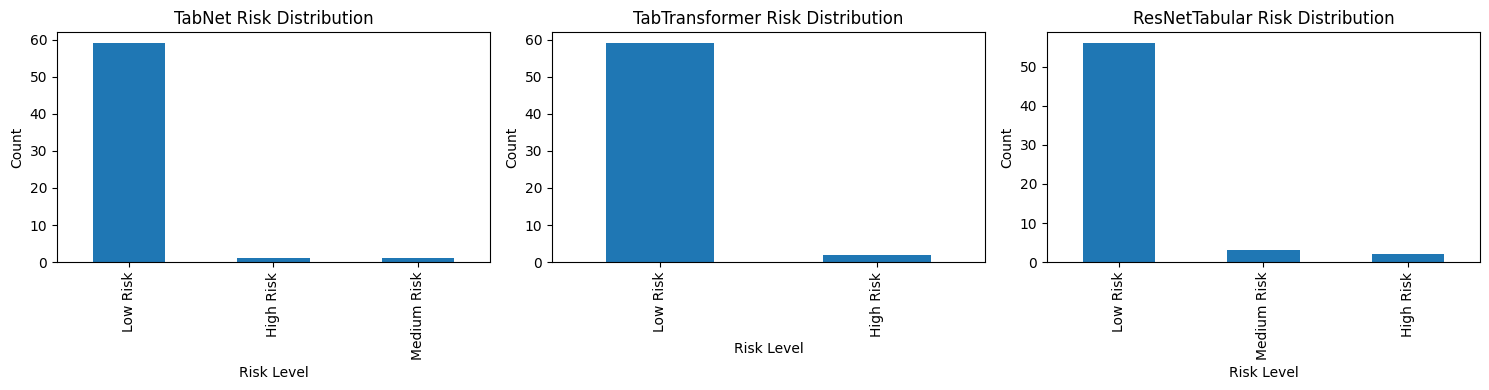

In [ ]:
# =========================
# RISK DISTRIBUTION GRAPHS
# =========================

risk_dfs = {
    "TabNet": results_tabnet,
    "TabTransformer": results_tabtransformer,
    "ResNetTabular": results_resnet
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, result_df) in zip(axes, risk_dfs.items()):
    counts = result_df["Risk_Level"].value_counts()
    counts.plot(kind="bar", ax=ax)
    ax.set_title(f"{name} Risk Distribution")
    ax.set_xlabel("Risk Level")
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

    Feature  Importance
2    BMXBMI    0.422601
1    PAQ605    0.207995
4     LBXIN    0.193599
0  RIAGENDR    0.109371
3    LBXGLT    0.066433


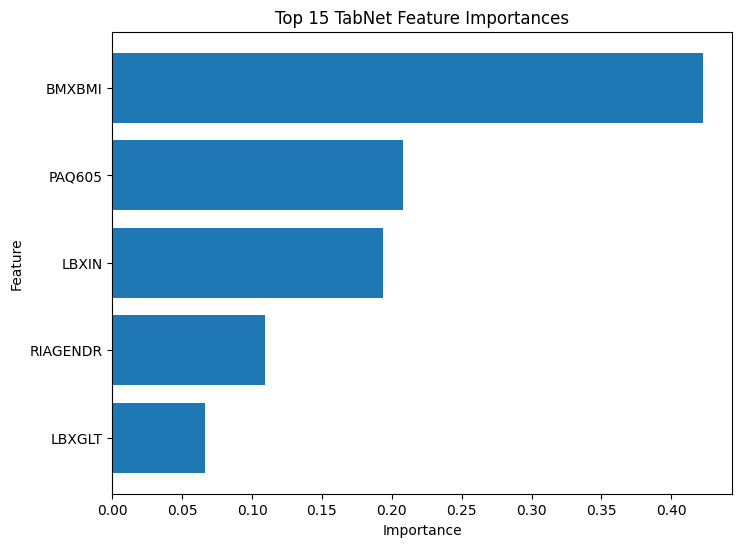

In [ ]:
# =========================
# TABNET FEATURE IMPORTANCE GRAPH
# =========================

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": tabnet_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(feature_importance.head(15))

plt.figure(figsize=(8, 6))
plt.barh(
    feature_importance["Feature"].head(15),
    feature_importance["Importance"].head(15)
)
plt.gca().invert_yaxis()
plt.title("Top 15 TabNet Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [ ]:
# =========================
# FINAL RESULT TABLE
# =========================

final_results = pd.DataFrame({
    "Model": ["TabNet", "TabTransformer", "ResNetTabular"],
    "Accuracy": [tabnet_acc, tabtransformer_acc, resnet_acc]
})

final_results

,Model,Accuracy
0,TabNet,0.967213
1,TabTransformer,0.950820
2,ResNetTabular,0.950820
